In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import mode

import matplotlib.pyplot as plt

In [22]:
import sys
sys.path.append("/Users/mariahloehr/IICD/IICD/feature_importance")

In [23]:
import locomp
from locomp import *
from locomp.MLmodels import *
from locomp.util_locomp import *
import itertools
import importlib
from sklearn.base import BaseEstimator, RegressorMixin, clone
import itertools
from functools import partial
import multiprocessing as mp
import re

import functions_case as il
import importlib

In [24]:
# Load data
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/T47D.csv")

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Separate features and target
X = df.drop(columns=['phase', 'Metadata_well'])
y = le.fit_transform(df['Metadata_well'])

feature_names = X.columns.tolist()
feature_pairs = list(itertools.combinations(range(X.shape[1]), 2))
X = X.to_numpy()
#y = y.to_numpy()

# Split data into train and test sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=949, stratify=y)

In [25]:
def xgbclass(X, Y):
    fit = GradientBoostingClassifier(
        n_estimators=10,       # fixed boosting rounds
        learning_rate=0.1, # hyperparameters from XGB model
        max_depth=7,
        random_state=949
    ).fit(X,Y)
    return fit

In [26]:
J1 = 0
J2 = 1
m_ratio = 0.5
n_ratio = 0.5
B = 5000
fit_func = xgbclass

In [27]:
predictions, in_mp_obs, in_mp_feature = predictMPClass(X_train, y_train, X_test, n_ratio, m_ratio, B, fit_func)

python(6407) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
python(6408) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6409) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6410) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6411) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6412) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6413) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6414) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6415) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(6416) MallocStackLogging: can't turn off mal

In [29]:
# 0.5 Step 1: convert one-hot predictions to class indices

from sklearn.metrics import accuracy_score, cohen_kappa_score

class_preds = predictions.argmax(axis=2)   # shape (B, N)

# Step 2: majority vote per sample
majority_vote = mode(class_preds, axis=0, keepdims=False).mode  # shape (N,)

# Define the mapping from class index → treatment label
class_labels = np.array([0, 1, 2, 3, 4])

# Convert indices to labels
mode_pred = class_labels[majority_vote]

acc = accuracy_score(y_test, mode_pred)
kappa = cohen_kappa_score(y_test, mode_pred)

print(f"Minipatch model accuracy: {acc:.3f}")
print(f"Minipatch model Cohen's kappa: {kappa:.3f}")

Minipatch model accuracy: 0.684
Minipatch model Cohen's kappa: 0.598


In [31]:
# save cohen results
# === Load existing results ===
results_df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/cancer_cohen_results.csv", index_col=0)

# === Insert values ===
model_name = "Boosted MP"
results_df.loc[model_name, "Cohen's Kappa"] = kappa

# === Save updated file ===
results_df.to_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/cancer_cohen_results.csv")

In [9]:
np.savez("encoded_xgb.npz", predictions=predictions, obs=in_mp_obs, feats=in_mp_feature)

In [9]:
# 0.5 Step 1: convert one-hot predictions to class indices
class_preds = predictions.argmax(axis=2)   # shape (B, N)

# Step 2: majority vote per sample
majority_vote = mode(class_preds, axis=0, keepdims=False).mode  # shape (N,)

# Define the mapping from class index → treatment label
class_labels = np.array([0, 1, 10, 100, 1000])

# Convert indices to labels
mode_pred = class_labels[majority_vote]

acc = accuracy_score(y_test, mode_pred)

print(f"Minipatch model accuracy: {acc:.3f}")

Minipatch model accuracy: 0.683


In [11]:
# === Load existing results DataFrame ===
results_df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/LOCO/cancer_mp_results.csv", index_col=0)

# === Set values ===
model_name = "Boosted MP"  # or whatever is appropriate
results_df.loc[model_name, 'Accuracy'] = acc

# === Save updated results ===
results_df.to_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/LOCO/cancer_mp_results.csv")

In [12]:
np.savez("ensemble_xgb.npz", predictions=predictions, obs=in_mp_obs, feats=in_mp_feature)

LOCO

In [7]:
x=LOCOMPClass(X,y,n_ratio,m_ratio,B,fit_func, selected_features=[],alpha=0.1,bonf=True)
x.run_loco()
#x.loco_ci

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/Users/mariahloehr/IICD/IICD/feature_importance/locomp/util_locomp.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  idx_I =Y_pd.groupby(0, group_keys=False).apply(lambda x: x.sample(frac=n_ratio))
/Users/mariahloehr/IICD/IICD/feature_importance/locomp/util_locomp.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  idx_I =Y_pd.groupby(0, 

In [6]:
ci_df =pd.read_csv('/Users/mariahloehr/IICD/IICD/Cancer treatment/LOCO/xgb_loco.csv')

In [7]:
#ci_df = pd.DataFrame(x.loco_ci)
ci_df = ci_df.rename(columns={2: 'lower_bound', 3: 'upper_bound', 4: 'score'})
ci_df['feature_name'] = feature_names
fig_df = ci_df.nlargest(10, "score")

In [8]:
import re

def rename_feature(name):
    if name.startswith("Intensity_MedianIntensity_"):
        return name.replace("Intensity_MedianIntensity_", "")
    
    return name

# Apply renaming
renamed_features = [rename_feature(col) for col in fig_df["feature_name"]]

In [9]:
fig_df["feature_name"] = renamed_features

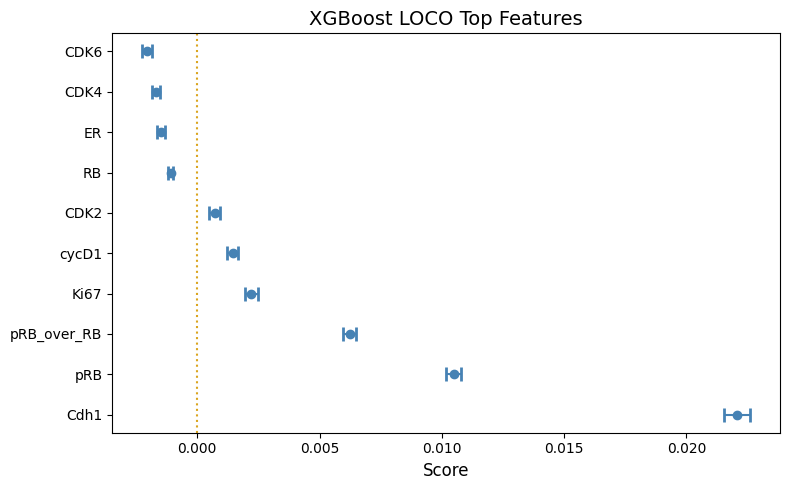

In [10]:
plt.figure(figsize=(8, 5))
plt.errorbar(
    fig_df["score"],
    fig_df["feature_name"],
    xerr=[fig_df["score"] - fig_df["lower_bound"], fig_df["upper_bound"] - fig_df["score"]],
    fmt="o", capsize=5, capthick=2, markersize=6, color="steelblue"
)
plt.axvline(x=0, color='goldenrod', linestyle='dotted')
plt.xlabel("Score", fontsize=12)
plt.yticks(fontsize=10)
plt.title("XGBoost LOCO Top Features", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
ci_df.to_csv('/Users/mariahloehr/IICD/IICD/Cancer treatment/LOCO/xgb_loco.csv', index=False)

iLOCO

In [7]:
def get_mp_metric(X, Y, n_ratio, m_ratio, B,
                   predictions, mp_observations, mp_features, 
                   model, feature_pairs):
    """
    Computes interaction metrics (iLOCO) for multiple feature pairs using an ensemble model.

    Parameters:
    X (numpy.ndarray): Feature matrix.
    Y (numpy.ndarray): Target variable.
    n_ratio (float): Ratio parameter for ensemble fitting.
    m_ratio (float): Ratio parameter for ensemble fitting.
    B (int): Number of bootstrap samples.
    model (object): Trained model for interaction computation.
    feature_pairs (list of tuples): List of tuples where each tuple contains two feature indices (j1, j2) for the feature pair.

    Returns:
    dict: Dictionary where keys are feature pairs (j1, j2) and values are dictionaries containing:
          - 'iloco': The mean interaction value.
          - 'iloco_max': The maximum interaction value, ensuring non-negative.
          - 'iloco_ratio': The ratio of iloco to the mean of r.
    """
    # Create and fit an ensemble model
    #ensemble = il.Ensemble(model).fit(X, Y, n_ratio, m_ratio, B)

    # Compute feature interactions for the given list of feature pairs
    result = il.featureInteractions(X, Y, n_ratio, m_ratio, B,
                                    predictions, mp_observations, mp_features,
                                    model, feature_pairs, bonferroni=True)

    return result

In [8]:
data = np.load("encoded_xgb.npz")

# Access arrays
predictions = data["predictions"]
mp_observations  = data["obs"]
mp_features  = data["feats"]

In [9]:
predictions = np.transpose(predictions, (1, 0, 2))

mp_observations = mp_observations.T  # → (n, B)

mp_features = mp_features.T  # → (n, F)

In [10]:
def xgbclass(X, Y):
    fit = GradientBoostingClassifier(
        n_estimators=10,       # fixed boosting rounds
        learning_rate=0.1, # hyperparameters from XGB model
        max_depth=7,
        random_state=949
    ).fit(X,Y)
    return fit

In [11]:
J1 = 0
J2 = 1
m_ratio = 0.5
n_ratio = 0.5
B = 5000
fit_func = xgbclass

In [12]:
mp_results = []
mp_ci = []
mp_results = get_mp_metric(X, y, n_ratio, m_ratio, B, 
                           predictions, mp_observations, mp_features, 
                           model = xgbclass, feature_pairs=feature_pairs)
mp_scores = [mp_results[(j, k)]['iloco'] for (j, k) in feature_pairs]
mp_ci = [mp_results[(j, k)]["ci"] for (j, k) in feature_pairs]

# Generate all pairwise combinations
pairwise_names = list(itertools.combinations(feature_names, 2))
# Convert each tuple to a single string
pairwise_names_str = [' & '.join(pair) for pair in pairwise_names]
data = {'feature': pairwise_names_str, 'scores': mp_scores, 'ci': mp_ci }
df = pd.DataFrame(data)

df.to_csv("cancer_iloco_xgb.csv", index=False)

In [ ]:
xgb_iloco = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/LOCO/cancer_iloco_xgb.csv")
df = pd.DataFrame(xgb_iloco)

In [13]:
import re

def rename_feature(name):
    if "Intensity_MedianIntensity_" in name:
        return name.replace("Intensity_MedianIntensity_", "")
    
    if "Intensity_IntegratedIntensity_" in name:
        return name.replace("Intensity_IntegratedIntensity_", "")
    
    return name

# Apply renaming
renamed_features = [rename_feature(col) for col in df["feature"]]

In [14]:
df["feature"] = renamed_features

In [15]:
top_20 = df.nlargest(10, "scores")

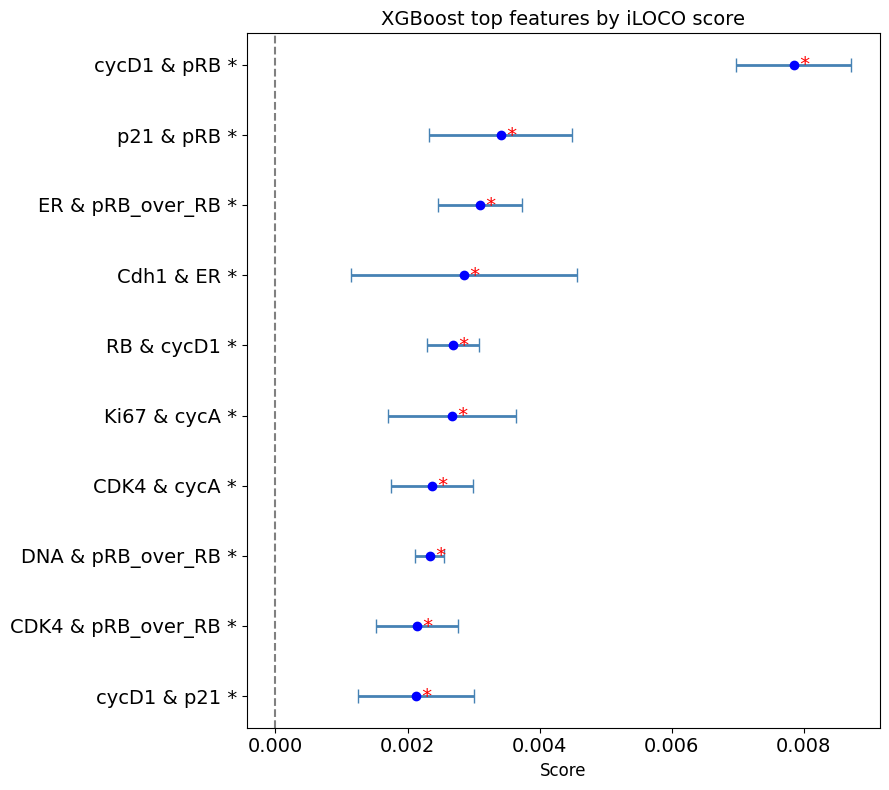

In [19]:
# Plot
# Copy feature names so we can modify them without affecting the original DataFrame
ytick_labels = top_20["feature"].copy()

# Add star next to feature names if CI does not include zero
for i, (score, ci) in enumerate(zip(top_20["scores"], top_20["ci"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    top_20["scores"],
    top_20["feature"],
    xerr=top_20["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)
plt.axvline(x=0, color='gray', linestyle='--')
plt.xticks(fontsize=14)  # Rotate x-axis labels vertically
plt.xlabel("Score", fontsize=12)
plt.title("XGBoost top features by iLOCO score", fontsize=14)

# Add stars for scores whose confidence intervals do not include 0
for i, (score, ci, feature) in enumerate(zip(top_20["scores"], top_20["ci"], top_20["feature"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(score, feature, " *", color='red', fontsize=14, va='center')

plt.yticks(ticks=top_20["feature"], labels=ytick_labels, fontsize=14)

plt.gca().invert_yaxis()  # Reverse y-axis

plt.tight_layout()
plt.show()

In [17]:
df["feature"] = renamed_features
bottom = df.nsmallest(10, "scores")

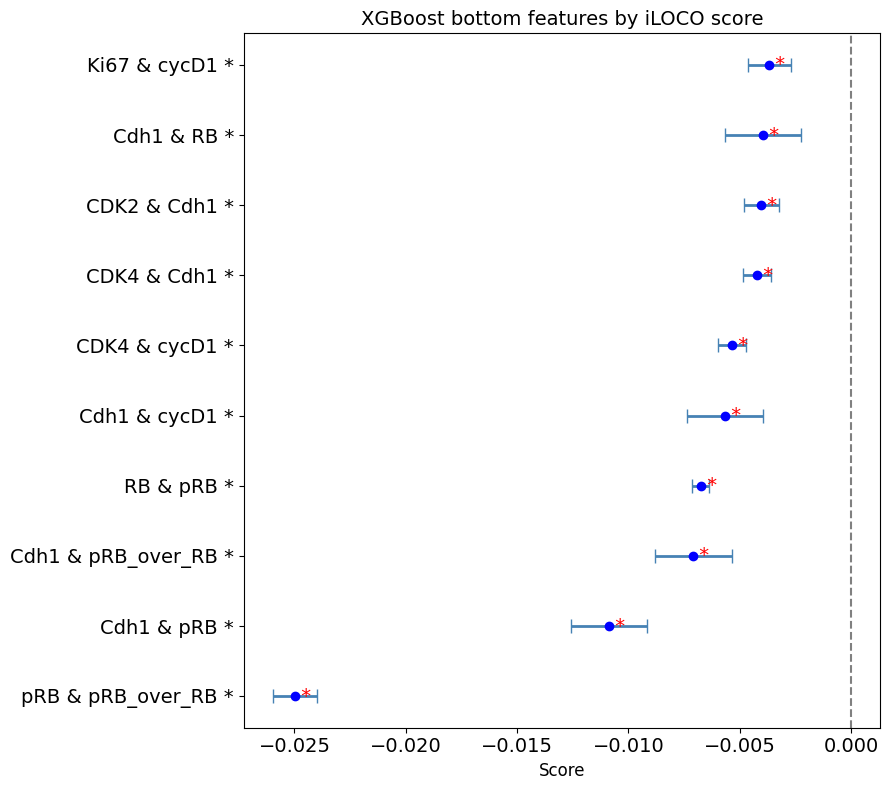

In [20]:
# Plot
ytick_labels = bottom["feature"].copy()

# Add star next to feature names if CI does not include zero
for i, (score, ci) in enumerate(zip(bottom["scores"], bottom["ci"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    bottom["scores"],
    bottom["feature"],
    xerr=bottom["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)

# Add stars for scores whose confidence intervals do not include 0
for i, (score, ci, feature) in enumerate(zip(bottom["scores"], bottom["ci"], bottom["feature"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(score, feature, " *", color='red', fontsize=14, va='center')

plt.axvline(x=0, color='gray', linestyle='--')
plt.yticks(ticks=bottom["feature"], labels=ytick_labels, fontsize=14)
plt.xticks(fontsize=14)  
plt.xlabel("Score", fontsize=12)
plt.title("XGBoost bottom features by iLOCO score", fontsize=14)
plt.tight_layout()  # Ensure everything fits nicely
plt.show()